### Import the Dataset

In [ ]:
with open("./datasets/names-v1.txt", 'r', encoding="utf-8") as file:
    dataset_content = file.read()

In [2]:
names = dataset_content.splitlines()

print(f"Number of names in the dataset: {len(names)}")
print(f"First 10 names in the dataset: {names[:10]}")

Number of names in the dataset: 32033
First 10 names in the dataset: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


### Extract All Unique Characters

In [3]:
chars = sorted(set(''.join(names)))

print(f"All Unique characters: {''.join([i if i != '\n' else '\\n' for i in chars])}")
print(f"Length: {len(chars)}")

All Unique characters: abcdefghijklmnopqrstuvwxyz
Length: 26


### Add Trigger Tokens

`<S>` : Start of the word

`<E>` : End of the word

In [4]:
start_token = "<S>"
end_token = "<E>"

chars.insert(0, start_token)
chars.insert(1, end_token)

print(f"All Unique characters: {''.join([i if i != '\n' else '\\n' for i in chars])}")
print(f"Length: {len(chars)}")

All Unique characters: <S><E>abcdefghijklmnopqrstuvwxyz
Length: 28


### Take Vocabulary Size (vocab_size)

Vocabulary size is the total number of unique characters in the dataset. It is important to determine the vocabulary size as it defines the dimensions of the bigram matrix and the one-hot encoding of characters.

In [5]:
vocab_size = len(chars)
print(f"Vocab size: {vocab_size}")

Vocab size: 28


### Character Tokenization: Encoding & Decoding | Create Mappings for Encoding and Decoding

To train a language model, text must be converted into numbers (**Encoding**) and turned back into text (**Decoding**). This is done using two complementary mappings: `stoi` (string-to-integer) and `itos` (integer-to-string).

| Process | Concept | Example | Purpose |
| --- | --- | --- | --- |
| **Encoding (`stoi`)** | Maps characters to unique index numbers. | 'a' $\rightarrow$ 0, 'b' $\rightarrow$ 1 | Converts text into numerical tensor inputs for the model. |
| **Decoding (`itos`)** | Maps index numbers back to characters. | 0 $\rightarrow$ 'a', 1 $\rightarrow$ 'b' | Converts the model's numerical outputs back into human-readable text. |

<br/>

$\text{"apple"} \xrightarrow{\text{Encode (stoi)}} [2, 4, 4, 6, 5] \xrightarrow{\text{Decode (itos)}} \text{"apple"}$

In [6]:
stoi = {char: index for index, char in enumerate(chars)} # string to integer -> map
itos = {index: char for index, char in enumerate(chars)} # integer to string -> map

print(f"stoi map: {stoi}")
print(f"itos map: {itos}")

stoi map: {'<S>': 0, '<E>': 1, 'a': 2, 'b': 3, 'c': 4, 'd': 5, 'e': 6, 'f': 7, 'g': 8, 'h': 9, 'i': 10, 'j': 11, 'k': 12, 'l': 13, 'm': 14, 'n': 15, 'o': 16, 'p': 17, 'q': 18, 'r': 19, 's': 20, 't': 21, 'u': 22, 'v': 23, 'w': 24, 'x': 25, 'y': 26, 'z': 27}
itos map: {0: '<S>', 1: '<E>', 2: 'a', 3: 'b', 4: 'c', 5: 'd', 6: 'e', 7: 'f', 8: 'g', 9: 'h', 10: 'i', 11: 'j', 12: 'k', 13: 'l', 14: 'm', 15: 'n', 16: 'o', 17: 'p', 18: 'q', 19: 'r', 20: 's', 21: 't', 22: 'u', 23: 'v', 24: 'w', 25: 'x', 26: 'y', 27: 'z'}


### Import PyTorch

In [7]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {torch.cuda.get_device_name(device) if device.type == 'cuda' else 'CPU'}")

torch.set_printoptions(sci_mode=False)
torch.set_printoptions(linewidth=400)

seed = 20060812

Using: NVIDIA GeForce RTX 4090


### Import Matplotlib

In [8]:
from matplotlib import pyplot as plt

---

# Bigram Model

The bigram model is a simple and weak language model that predicts the next character based on the previous character using only two characters at a time.


Initialize a zero-filled matrix of shape (vocab_size, vocab_size) to store the bigram counts.

In [9]:
N = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)

N.shape

torch.Size([28, 28])

Populate the bigram matrix by mapping each character pair's frequency to its corresponding row and column coordinates

In [10]:
for name in names:
    characters = [start_token] + list(name) + [end_token]
    for ch1, ch2 in zip(characters, characters[1:]):
        x = stoi[ch1]
        y = stoi[ch2]

        N[x, y] += 1

N

tensor([[   0,    0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963, 1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,  134,  535,  929],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
        [   0, 6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182, 2050,  435],
        [   0,  114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,   83,    0],
        [   0,   97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,  104,    4],
        [   0,  516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,   30,   31,  378,

Plot the bigram matrix as a heatmap to analyze character transition frequencies across the dataset.

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

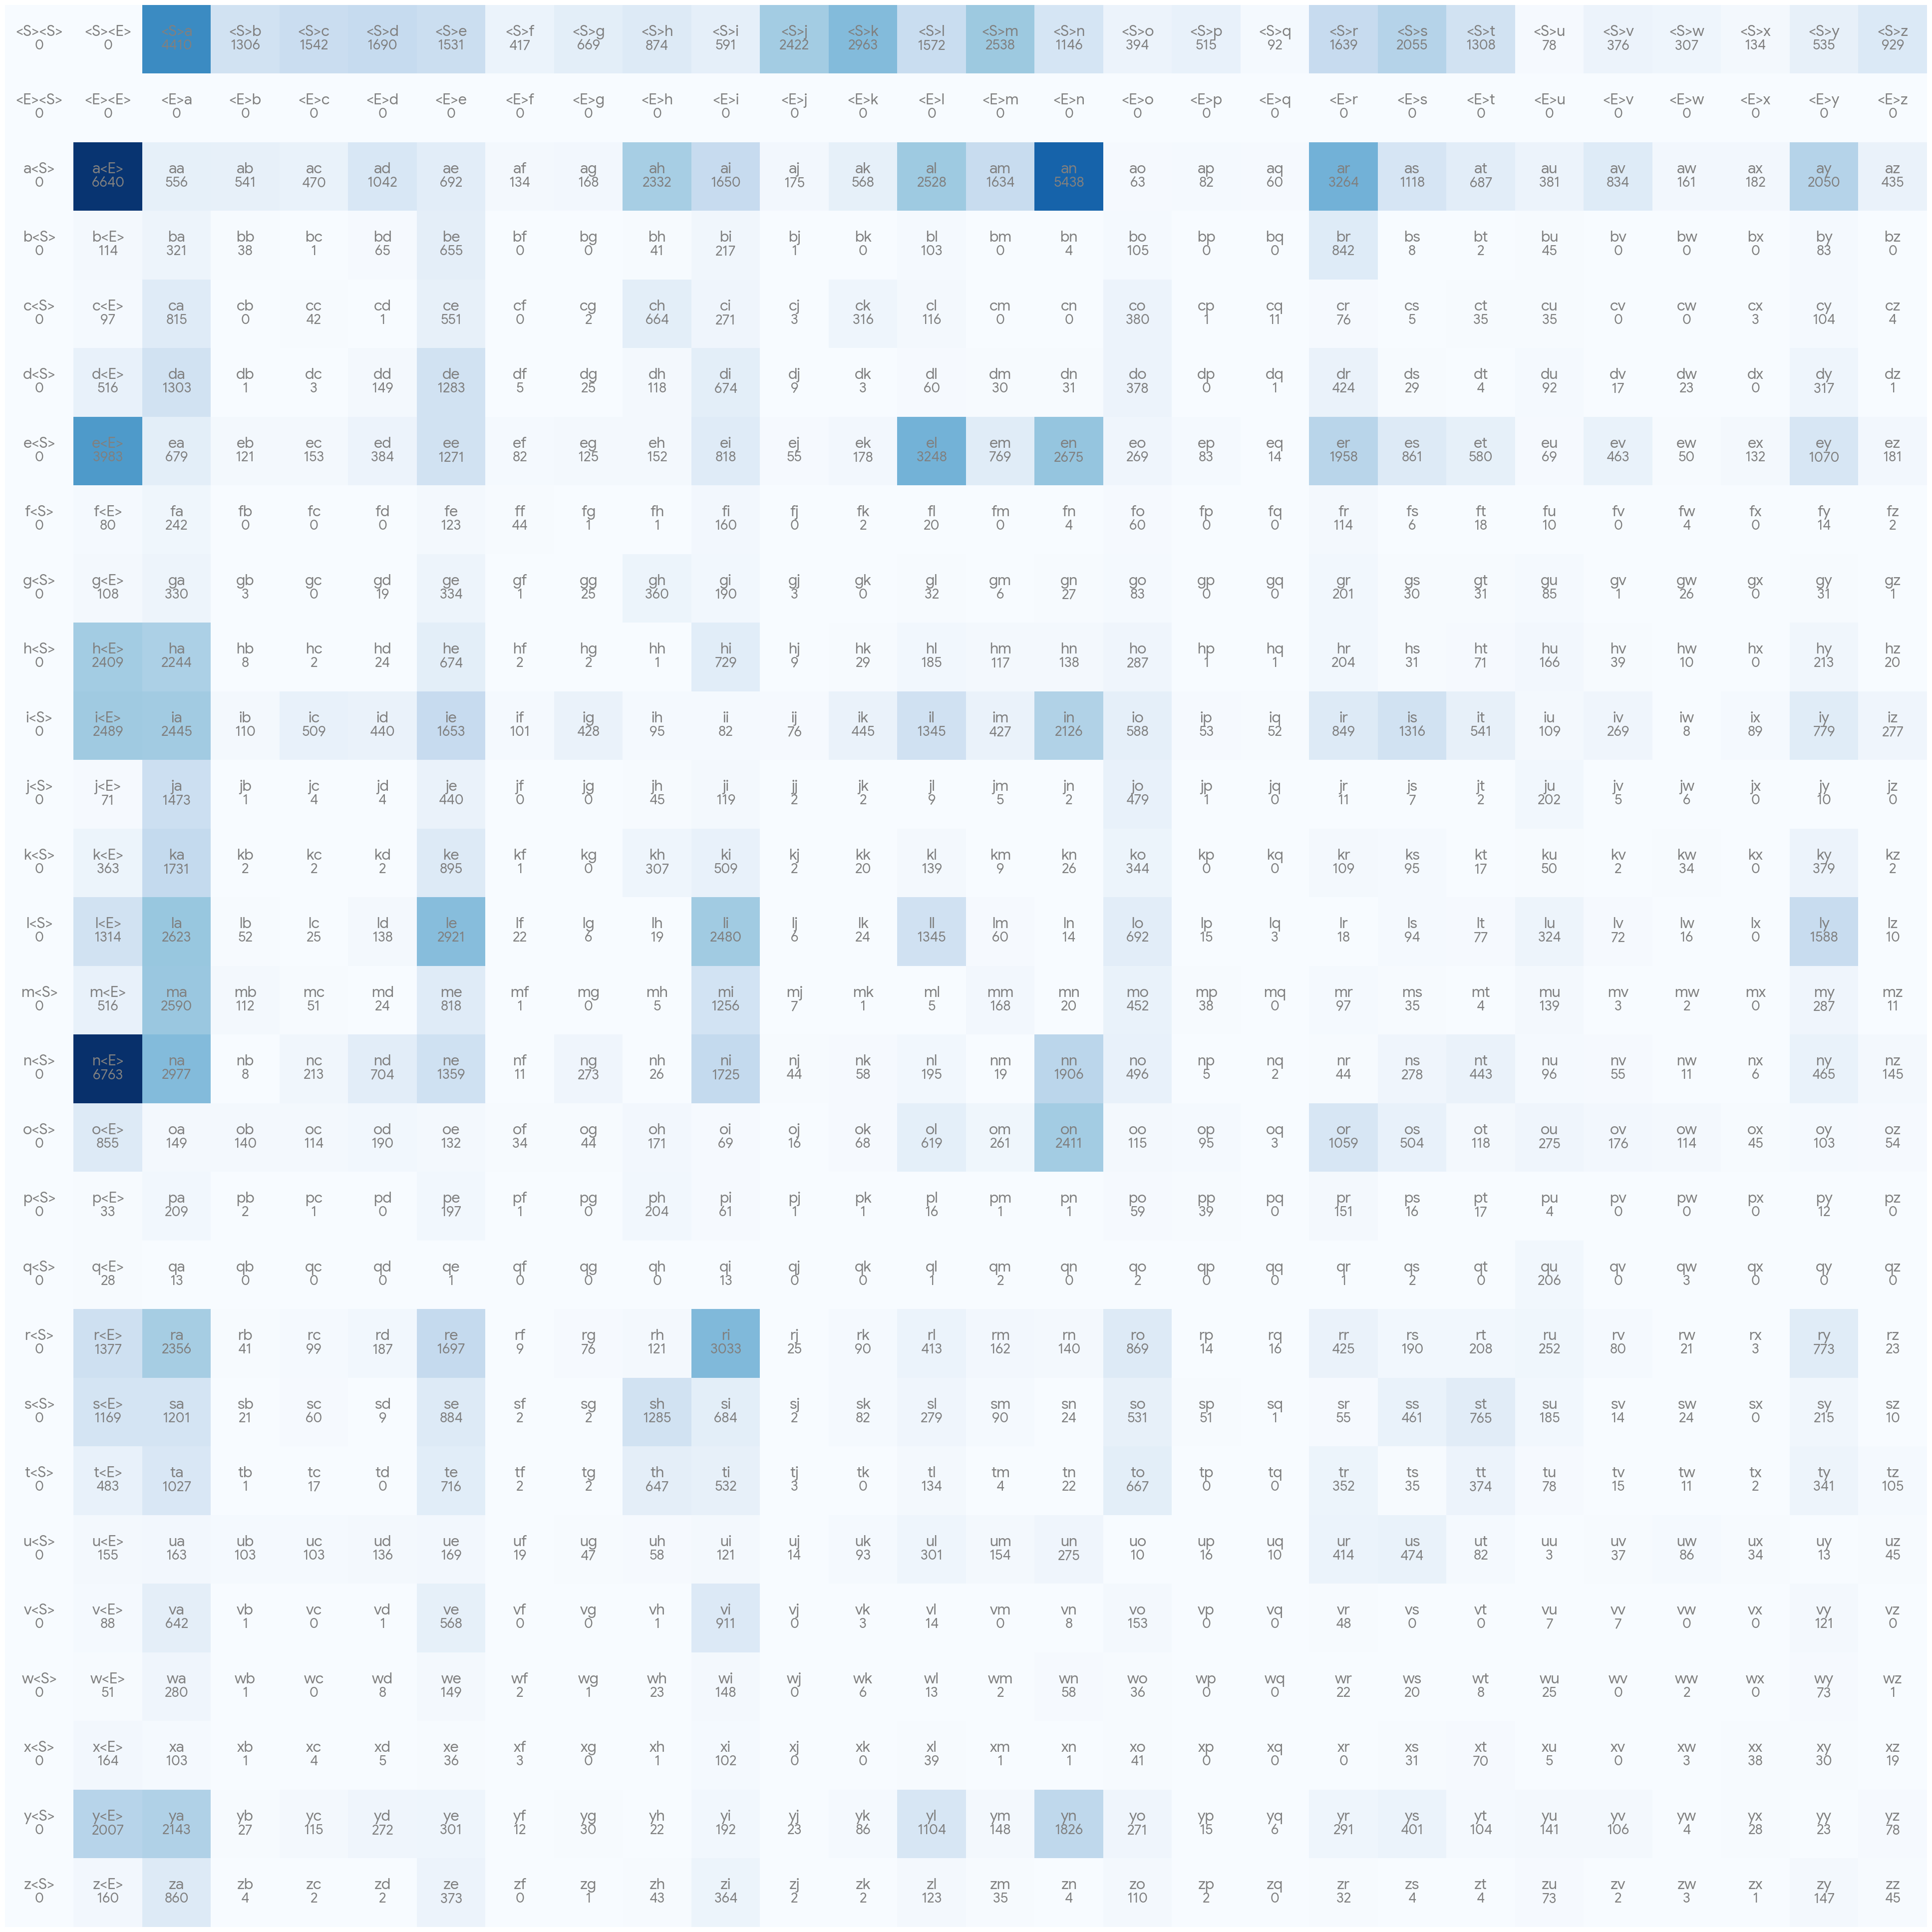

In [ ]:
plt.rcParams['font.family'] = 'Google Sans'
plt.rcParams['font.size'] = 14

plt.figure(figsize=(50, 50)) # v1 = 50, 50 | v2 = 100, 80
plt.imshow(N.cpu(), cmap='Blues')

for i in range(vocab_size):
    for k in range(vocab_size):
        pair = itos[i] + itos[k]
        plt.text(k, i, pair, ha="center", va="bottom", color="gray", fontsize=22)
        plt.text(k, i, N[i, k].item(), ha="center", va="top", color="gray", fontsize=20)
plt.axis("off")

### Normalize the Rows in Bigram Matrix into Probabilities


Each row of the matrix is normalized into a probability distribution. This is achieved by dividing each individual count by its total row sum, ensuring that the probabilities across any given row add up to exactly $1.0$ (sometimes it's approximately $1.0$ due to floating-point precision).

In [12]:
row = N[0].float()
probs = row / row.sum()


print(f"1st Row:               {row.tolist()}\n")
print(f"Row Sum:               {row.sum()}\n")
print(f"Probabilities:         {[float(f'{p:.4f}') for p in probs.tolist()]}\n")
print(f"Sum of Probabilities:  {probs.sum().item():.1f}")

1st Row:               [0.0, 0.0, 4410.0, 1306.0, 1542.0, 1690.0, 1531.0, 417.0, 669.0, 874.0, 591.0, 2422.0, 2963.0, 1572.0, 2538.0, 1146.0, 394.0, 515.0, 92.0, 1639.0, 2055.0, 1308.0, 78.0, 376.0, 307.0, 134.0, 535.0, 929.0]

Row Sum:               32033.0

Probabilities:         [0.0, 0.0, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.013, 0.0209, 0.0273, 0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029, 0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.029]

Sum of Probabilities:  1.0


### Multinomial Sampling

To generate completely new words, we use multinomial sampling to turn our static probability matrix to predict the next character. This process starts at the row there the start token has sampled in the matrix (usually index '0')

When we isolate a specific row from our normalized matrix, N[ix], we get a 1D tensor representing a probability distribution over the 28 possible next characters.

Passing this row into torch.multinomial(..., num_samples=1) is equivalent to spinning a biased roulette wheel where the slot sizes match our percentages. PyTorch rolls a single random index based on those odds. We use that character and navigate to the row with that sampled character as the new current row. This becomes repeating this chain reaction until it hits the end token.

In [ ]:
# Generator is used for reproducibility, ensuring that the same output is generated each time the code is run.
generator = torch.Generator().manual_seed(seed)

# This gives the starting pair "<S> + letter" from the bigram matrix, which is the first row (index 0) of the matrix.
ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=generator).item()

# This converts the sampled index back to its corresponding character using the itos mapping.
itos[ix]

'i'

### Combining Normalization and Multinomial Sampling

In [ ]:
# [For Testing Purpose]
# To see what happens if we have a uniform distribution where all characters have equal probability of being selected as the next character (equally likely to be sampled)
# N_uniform = torch.ones((vocab_size, vocab_size), dtype=torch.int32)

# Generator is used for reproducibility, ensuring that the same output is generated each time the code is run.
generator = torch.Generator().manual_seed(seed)

generated_names = []
for i in range(20):
    ix = 0
    bucket = []

    while True:
        row = N[ix].float()
        probs = row / row.sum()
        # print(f"probs: {probs} | sum: {probs.sum()}")

        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=generator).item()
        # print(ix, itos[ix])

        # until it gives '<E>'
        if itos[ix] == end_token:
            break

        bucket.append(itos[ix])

    generated_names.append(''.join(bucket))

print('\n'.join(generated_names))


ialgastanzayandakaruri
kavas
r
saelixy
bryassonn
aravendrerenahana
ja
samyla
jelin
rush
mi
o
a
chaje
sa
adi
alievaha
ariste
da
bsato


### Efficiency Improvements

Instead of using slow Python loops to normalize each row one by one, we can utilize PyTorch Broadcasting to perform the entire operation as a vectorized, in-place command. This significantly boosts performance and reduces memory overhead.

1. **Matrix Smoothing (Laplace Smoothing)**
    - When a character pair never appears in the dataset (such as an end-token trying to start a new word), its entire row in the matrix is filled with zeros. If we try to divide by that row's sum (which is zero), the code crashes with a division-by-zero error, resulting in `NaN` values. To prevent this, we smooth the entire matrix by adding a count of 1 to every single cell before calculating our probabilities.

<br/>

2. **Row Summation Metrics**
    - **Dimension 0 ($1 \times 28$):** Computes the sum of all columns individually.
    - **Dimension 1 ($28 \times 1$):** Computes the sum of all rows individually.
    - **`keepdim=True`:** Retains the reduced dimension as a singleton column vector ($28 \times 1$) instead of squeezing it into a flat 1D tensor ($28$,), which is strictly required for subsequent broadcasting operations.

<br/>

2. **Vectorized Normalization via Broadcasting**
    - **Method 1 (Iterative Loop):** <br/>
        Normalizing individual rows using a standard Python `for` loop introduces significant interpreter overhead and is highly computationally inefficient.
    - **Method 2 (Broadcasting):** <br/>
        Normalizing every row of the entire matrix simultaneously via broadcasting is much faster and more efficient. This method divides each row by its corresponding row sum in a single operation, leveraging PyTorch's optimized tensor computations.

        Two tensors are structurally "broadcastable" if, when iterating over their dimension sizes starting from the trailing dimension (right to left), the respective dimensions meet any of the following criteria:
        
        - The dimension sizes are exactly equal.
        - One of the dimension sizes is $1$.
        - One of the dimensions does not exist.

        ```text
        28, 28  <--- Shape of the bigram matrix (N_prob)
        28,  1  <--- Shape of the row sums      (N_ROW_SUM)
        ```

        Because the trailing dimension of `N_ROW_SUM` is $1$, PyTorch automatically expands it along that axis to match the $28 \times 28$ shape of `N_prob`. The operation utilizes the in-place operator (`/=`) to modify the tensor data directly in memory, optimizing our computational footprint.

---

<br/>

> **Why add 1 to the matrix instead of the row sum?**
>
> You might think: Why not just use a shortcut and add 1 to the row sum to stop the zero-division? 
> 
> Since the standard requires every row in a probability distribution to sum strictly to 1, incrementing the sum by 1 is problematic because it yields mathematically incorrect probabilities. Doing so shrinks the odds of your real data without spreading that leftover probability anywhere. Conversely, incrementing the entire bigram matrix by 1 applies proper Laplace smoothing, creating a mathematically perfect, uniform baseline for unseen characters.

> **Why didn't the `for loop` method crash originally when executing `probs = row / row.sum()`?**
>
> Because `ix` starts at 0 ($<S>$) and sequentially moves only to characters that actually exist in the dataset, we were only ever loading rows that had a sum greater than zero. Rows for characters that never appeared in the training data—or the end token row `N[1]`, which is entirely filled with zeros because nothing can follow $<E>$—are completely bypassed by the generator loop. Since the loop breaks the moment `ix` hits 1 ($<E>$), we stop execution before moving to row 1, meaning we never actually encounter the division-by-zero error.

In [15]:
# 1. Matrix Smoothing (Laplace Smoothing)
N_prob = N.to(torch.float32)
N_prob += 1.0


# 2. Row Summation Metrics
N_ROW_SUM = N_prob.sum(1, keepdim=True)


# 3. Vectorized Normalization via Broadcasting

# Method 1: Using for loop
# for index, row in enumerate(N_prob):
#    N_prob[index] = row / N_ROW_SUM[index].item()

# Method 2: Using broadcasting
# In place operation to save memory
# N_prob = N_prob / N_ROW_SUM
N_prob /= N_ROW_SUM


# Generator is used for reproducibility, ensuring that the same output is generated each time the code is run.
generator = torch.Generator().manual_seed(seed)

generated_names = []
for i in range(20):
    ix = 0
    bucket = []

    while True:
        probs = N_prob[ix]
        # print(f"probs: {probs} | sum: {probs.sum()}")

        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=generator).item()
        # print(ix, itos[ix])

        # until it gives '<E>'
        if itos[ix] == end_token:
            break

        bucket.append(itos[ix])

    generated_names.append(''.join(bucket))

print('\n'.join(generated_names))

ialgastanzayandakaruri
kavas
r
saelixy
bryassonn
aravendrerenahana
ja
samyla
jelin
rush
mi
o
a
chaje
sa
adi
alievaha
ariste
da
bsato


### Quality Check: Baseline Uniform Distribution

When evaluating a language model, it is helpful to establish a baseline using a **uniform probability distribution**. If a model makes completely random predictions because it hasn't learned any patterns yet, every unique character (token) has an equal likelihood of being chosen next.

The uniform probability for any given character is calculated as:

$$\text{Baseline Probability} = \frac{1}{\text{vocab\_size}}$$

In [16]:
baseline_prob = 1 / vocab_size
print(f"{baseline_prob=}")

baseline_prob=0.03571428571428571


Value above `1 / vocab_size` indicates that the model has learned some patterns in the data. (Well trained model should have near 1 probabilities)

In [17]:
for name in names[:3]:
    characters = [start_token] + list(name) + [end_token]
    for ch1, ch2 in zip(characters, characters[1:]):
        x = stoi[ch1]
        y = stoi[ch2]

        prob = N_prob[x, y]

        # trained vs baseline
        print(f"{ch1}{ch2} {' ' * (5 - len(f'{ch1}{ch2}'))}: {prob:.4f} {'↑' if prob > baseline_prob else '↓'} | {baseline_prob:.4f}")

    print("-" * 25)

<S>e  : 0.0478 ↑ | 0.0357
em    : 0.0377 ↑ | 0.0357
mm    : 0.0253 ↓ | 0.0357
ma    : 0.3885 ↑ | 0.0357
a<E>  : 0.1958 ↑ | 0.0357
-------------------------
<S>o  : 0.0123 ↓ | 0.0357
ol    : 0.0779 ↑ | 0.0357
li    : 0.1774 ↑ | 0.0357
iv    : 0.0152 ↓ | 0.0357
vi    : 0.3506 ↑ | 0.0357
ia    : 0.1380 ↑ | 0.0357
a<E>  : 0.1958 ↑ | 0.0357
-------------------------
<S>a  : 0.1376 ↑ | 0.0357
av    : 0.0246 ↓ | 0.0357
va    : 0.2472 ↑ | 0.0357
a<E>  : 0.1958 ↑ | 0.0357
-------------------------


### Quality Check: Likelihood, Log-Likelihood, Negative Log-Likelihood, and Average Negative Log-Likelihood (Loss Function)

To evaluate the quality of a statistical language model, we mathematically measure how well it predicts our training text. This process evolves from raw joint probability into our final standardized loss function.

#### 1. Joint Likelihood and the Underflow Problem

The **likelihood** of a sequence of characters is calculated as the product of the probabilities of each individual character transition in that sequence.

$$\text{Likelihood} = P_1 \times P_2 \times P_3 \times \dots \times P_N$$

* **The Problem:** Because probabilities are always small fractions between $0$ and $1$, multiplying thousands of them together causes the value to shrink exponentially. This leads to **numerical underflow**, where the result becomes too small for a computer to represent accurately, rounding down to an absolute `0.0`.

#### 2. Log-Likelihood (LL)

To address the underflow problem, we apply a logarithmic transformation. Leveraging the fundamental logarithmic property where the log of a product equals the sum of individual logs, we turn a dangerous multiplication chain into a safe addition chain. This transformation allows us to work with stable numbers without losing precision.

$$\text{LL Loss (log likelihood)} = \sum_{i=1}^{N} \log(P_i)$$

#### 3. Negative Log-Likelihood (NLL)

Because probabilities are bounded between $0$ and $1$, the logarithm of any probability will always yield a negative number (or exactly $0.0$ if the probability is a perfect $1.0$).

**Negative Log-Likelihood (NLL)** is simply the negative of the log-likelihood. It is commonly used as a loss function in machine learning because it converts the maximization problem of likelihood into a minimization problem, which is far more convenient and standard for optimization algorithms.

$$\text{NLL Loss (negative log likelihood)} = -\sum_{i=1}^{N} \log(P_i)$$

#### 4. Average Negative Log-Likelihood (The Actual Loss Function)

To make our metric independent of the dataset's size, we compute the average by dividing the total NLL by the total number of processed pairs ($n$).

$$\text{AVG. NLL Loss (avg. negative log likelihood)} = -\frac{1}{n} \sum_{i=1}^{N} \log(P_i)$$

* **The Core Metric:** This average negative log-likelihood loss is calculated by taking the negative of the sum of the log probabilities and dividing it by the number of bigrams in the dataset.
* **Defining $n$:** Here, $n$ represents the total number of bigrams in the dataset. This explicitly includes duplicate bigrams, meaning the exact same bigram transition will contribute multiple times to the total loss because it represents a real prediction step.
* **Evaluating Model Quality:** This score directly reflects the quality of the model. The lower the loss is (approaching zero), the better the model is at predicting the sequence. Conversely, the higher the loss is, the worse the model's predictive performance is.
* **PyTorch Integration:** This mathematical formula is identical to the operations performed under the hood by `torch.nn.functional.nll_loss(...)` and `torch.nn.CrossEntropyLoss(...)` in PyTorch, which are the standard industry tools used for training language models.

---

#### Logarithmic Properties

The following fundamental logarithmic identities make the transition from Likelihood multiplication to Log-Likelihood addition possible:

* $\log(a \times b \times c) = \log(a) + \log(b) + \log(c)$ *(Product Rule)*
* $\log(\frac{a}{b}) = \log(a) - \log(b)$ *(Quotient Rule)*
* $\log(a^b) = b \times \log(a)$ *(Power Rule)*
* $\log(1) = 0$ *(Upper Bound for perfect $100\%$ probability)*
* $\log(0) = -\infty$ *(Lower Bound for impossible $0\%$ probability)*

*Visual Representation: Log(x) from 0 to 1 as it slopes down to negative infinity.*

![Log(x)](./assets/log(x).png)



> Since a well-trained model should have character prediction probabilities close to $1$, its individual log-likelihood components will naturally hover close to $0$ ($\log(1) = 0$). Ultimately, the closer the total log-likelihood is to $0$, the better and more accurate the model is at predicting the final sequence.

In [18]:
likelihood = 1.0
log_likelihood = 0.0
neg_log_likelihood = 0.0
avg_neg_log_likelihood = 0.0

n = 0

for name in names:
    characters = [start_token] + list(name) + [end_token]
    for ch1, ch2 in zip(characters, characters[1:]):
        x = stoi[ch1]
        y = stoi[ch2]

        prob = N_prob[x, y]

        likelihood *= prob # AND operation aka Joint Probability
        log_likelihood += torch.log(prob)
        neg_log_likelihood += -torch.log(prob)

        n += 1

        # trained vs baseline
        # print(f"{ch1}{ch2} {' ' * (5 - len(f'{ch1}{ch2}'))}: {prob:.4f} {'↑' if prob > baseline_prob else '↓'} | {baseline_prob:.4f}")

    # print("-" * 25)


avg_neg_log_likelihood = neg_log_likelihood / n

print(f"Total number of bigram pairs: {n}")
print(f"Likelihood: {likelihood:.4e}")
print(f"Log Likelihood: {log_likelihood:.4f}")
print(f"Negative Log Likelihood: {neg_log_likelihood:.4f}")
print(f"Average Negative Log Likelihood (loss): {avg_neg_log_likelihood:.4f}")


Total number of bigram pairs: 228146
Likelihood: 0.0000e+00
Log Likelihood: -559978.7500
Negative Log Likelihood: 559978.7500
Average Negative Log Likelihood (loss): 2.4545


### Testing Probabilities for Words

Below function is to test the probabilities for a single word.

In [19]:
def get_probs(names: list) -> None:

    for name in names:
        likelihood = 1.0
        log_likelihood = 0.0
        neg_log_likelihood = 0.0
        avg_neg_log_likelihood = 0.0

        n = 0

        characters = [start_token] + list(name) + [end_token]
        for ch1, ch2 in zip(characters, characters[1:]):
            x = stoi[ch1]
            y = stoi[ch2]

            prob = N_prob[x, y]

            likelihood *= prob # AND operation aka Joint Probability
            log_likelihood += torch.log(prob)
            neg_log_likelihood += -torch.log(prob)

            n += 1

        avg_neg_log_likelihood = neg_log_likelihood / n

        print(f"Evaluating: {name}")
        print(f"Total number of bigram pairs: {n}")
        print(f"Likelihood: {likelihood:.4e}")
        print(f"Log Likelihood: {log_likelihood:.4f}")
        print(f"Negative Log Likelihood: {neg_log_likelihood:.4f}")
        print(f"Average Negative Log Likelihood: {avg_neg_log_likelihood:.4f}")

        print("-" * 25)


get_probs(["anna", "ann", "sophia", "soph", "john", "johnny"])

Evaluating: anna
Total number of bigram pairs: 5
Likelihood: 7.2836e-05
Log Likelihood: -9.5273
Negative Log Likelihood: 9.5273
Average Negative Log Likelihood: 1.9055
-------------------------
Evaluating: ann
Total number of bigram pairs: 4
Likelihood: 8.4481e-04
Log Likelihood: -7.0764
Negative Log Likelihood: 7.0764
Average Negative Log Likelihood: 1.7691
-------------------------
Evaluating: sophia
Total number of bigram pairs: 7
Likelihood: 2.5378e-08
Log Likelihood: -17.4894
Negative Log Likelihood: 17.4894
Average Negative Log Likelihood: 2.4985
-------------------------
Evaluating: soph
Total number of bigram pairs: 5
Likelihood: 3.1011e-06
Log Likelihood: -12.6838
Negative Log Likelihood: 12.6838
Average Negative Log Likelihood: 2.5368
-------------------------
Evaluating: john
Total number of bigram pairs: 5
Likelihood: 1.7935e-06
Log Likelihood: -13.2314
Negative Log Likelihood: 13.2314
Average Negative Log Likelihood: 2.6463
-------------------------
Evaluating: johnny
Tota

---

The GOAL is to maximize the Joint Likelihood and by extension, the Log-Likelihood of the bigram character pairs across the training dataset. In other words, reducing the Average Negative Log-Likelihood (NLL) loss function.

Neural Networks approach sequence prediction entirely differently than classical frequency counting. Instead of manually tallying bigram frequencies into an explicit lookup table, a neural network optimizes continuous parameter weights ($W$) to learn the implicit statistical patterns and structural relationships between characters. This optimization framework allows neural networks to capture more nuanced dependencies and generalize far better to unseen data, surpassing the strict limitations of a purely deterministic count model.

**A single-layer neural network with a Softmax output layer is mathematically equivalent to the traditional statistical bigram model.**

The ultimate distinction lies in architectural scaling. While a classical bigram model is hard-capped by the physical memory layout of a frequency table (which scales poorly as context length grows), a neural network operates as a flexible function approximator. Scaling a neural network is as simple as adding hidden layers between the input and output. By transitioning from this single-layer setup to a deep, multi-layer architecture, the network can seamlessly learn highly complex, high-dimensional data patterns and capture deep non-linear relationships that a flat frequency table could never represent.

---